## Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset Documentation

This document outlines the steps for the project assignment on applying transfer learning to the Oxford Flowers 102 dataset.

**Objective:** Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset:** Oxford Flowers 102 - A dataset of 102 categories of flowers. You will load this dataset using TensorFlow Datasets.

**Assignment Steps:**

1.  **Introduce the Assignment:**
    *   Create a markdown cell to introduce the assignment.
    *   Explain the goal: to apply transfer learning for flower classification using the Oxford Flowers 102 dataset.
    *   Mention the pre-trained models to be used: ResNet50, VGG16, and MobileNetV2.
    *   Briefly describe the Oxford Flowers 102 dataset.

2.  **Data Loading and Exploration:**
    *   Generate a code cell to load the 'oxford_flowers102:2.1.1' dataset using `tfds.load()`. (Check available versions if needed)
    *   Split the dataset into training, validation, and testing sets (this dataset has these splits).
    *   Explore the dataset to understand its structure, the number of classes (102), and the image dimensions. You can display some sample images and their labels.

3.  **Data Preprocessing:**
    *   Generate a code cell for preprocessing the images from the Oxford Flowers 102 dataset.
    *   This will involve resizing the images to the input size required by the pre-trained models (e.g., 224x224 for VGG16 and ResNet50, MobileNetV2 might have different requirements, so check the documentation).
    *   Apply the model-specific preprocessing functions (e.g., `tf.keras.applications.resnet50.preprocess_input`) to normalize the pixel values.
    *   Apply one-hot encoding to the labels.
    *   Batch and prefetch the datasets for efficient training.

4.  **Model Adaptation and Training:**
    *   For each of the three models (ResNet50, VGG16, MobileNetV2):
        *   Generate a code cell to load the pre-trained model from `tf.keras.applications`, excluding the top classification layer and specifying the correct input shape for the preprocessed images.
        *   Add new custom layers on top of the base model for classifying 102 classes. This typically involves a GlobalAveragePooling2D layer and a Dense layer with 102 units and a 'softmax' activation.
        *   Freeze the layers of the pre-trained base model.
        *   Compile the model with an appropriate optimizer (e.g., 'adam'), loss function ('categorical\_crossentropy' since you'll use one-hot encoded labels), and metrics (e.g., 'accuracy').
        *   Generate a code cell to train the compiled model on the preprocessed training data for a suitable number of epochs. Use the validation data to monitor performance during training. Consider using callbacks like ModelCheckpoint and EarlyStopping.
        *   Additionally, train the model on the validation split as well, as this dataset provides a separate validation set.
        *   Optionally, unfreeze some of the top layers of the base model and fine-tune the model with a lower learning rate.

5.  **Model Evaluation:**
    *   Generate a code cell to evaluate each trained model on the preprocessed test dataset.
    *   Print the loss and accuracy for each model.

6.  **Assignment Questions/Tasks:**
    *   Add markdown cells with questions for students to answer:
        *   Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?
        *   Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100 (from the original notebook). What differences do you observe and why?
        *   Discuss the effect of transfer learning on this dataset.
        *   Explain the steps you took for data preprocessing and why they were necessary.
        *   Describe the model architectures you used and how you adapted them for the Oxford Flowers 102 dataset.
        *   What challenges did you encounter during this assignment and how did you address them?
    *   Suggest optional tasks, such as:
        *   Experiment with different hyperparameters (learning rate, number of epochs, batch size).
        *   Implement data augmentation techniques.
        *   Try fine-tuning different numbers of layers.
        *   Visualize sample predictions and analyze misclassifications.

7.  **Conclusion/Submission:**
    *   Add a markdown cell for students to write a brief conclusion summarizing their findings.
    *   Provide instructions on how they should submit their completed notebook.

# **Assignment Objective**

 Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, MobileNetV2 etc.) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset**: Oxford Flowers 102 - A dataset of 102 categories of flowers.

## **Loading the Dataset**

In [1]:
import tensorflow_datasets as tfds

# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.AQ8Y31_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.AQ8Y31_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see

## **Exploring the Dataset**

In [2]:
print("Dataset location:", info.data_dir)

Dataset location: /root/tensorflow_datasets/oxford_flowers102/2.1.1


In [3]:
# Get the label names from the info object
label_names = info.features['label'].names

# Print the first 10 label names
print("First 10 label names:", label_names[:10])

# Print the total number of labels
print("Total number of labels:", len(label_names))

First 10 label names: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle']
Total number of labels: 102


In [4]:
# Take one image and label from the training dataset
for image, label in train_dataset.take(1):
    break # Exit the loop after taking one element

# Print the shape of the image
print("Shape of a single image:", image.shape)

Shape of a single image: (500, 667, 3)


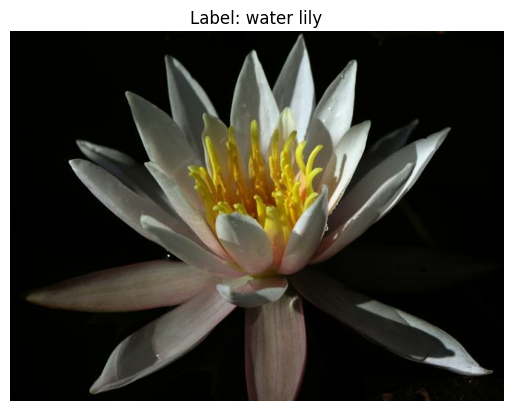

In [5]:
import matplotlib.pyplot as plt

# Take one image and label from the training dataset
for image, label in train_dataset.take(1):
    break # Exit the loop after taking one element

# Get the label name
label_name = info.features['label'].names[label.numpy()]

# Display the image and label
plt.figure()
plt.imshow(image.numpy())
plt.title(f"Label: {label_name}")
plt.axis("off")
plt.show()

# **Preprocessing the Dataset**

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = 224 # Define the image size expected by the models

def preprocess_image(image, label):
    # Resize the image to the desired size
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Convert image to float32 and normalize pixel values
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply the preprocessing function to the datasets
train_dataset_preprocessed = train_dataset.map(preprocess_image).batch(32)
validation_dataset_preprocessed = validation_dataset.map(preprocess_image).batch(32)
test_dataset_preprocessed = test_dataset.map(preprocess_image).batch(32)

print("Preprocessing complete. Datasets are now batched and ready for model training.")

# # Take a batch from the preprocessed training dataset
# for images, labels in train_dataset_preprocessed.take(1):
#     plt.figure(figsize=(10, 10))
#     for i in range(9):
#         ax = plt.subplot(3, 3, i + 1)
#         plt.imshow(images[i])
#         plt.title(label_names[labels[i].numpy()])
#         plt.axis("off")
#     plt.show()

Preprocessing complete. Datasets are now batched and ready for model training.


### **Original vs Preprocessed Images**

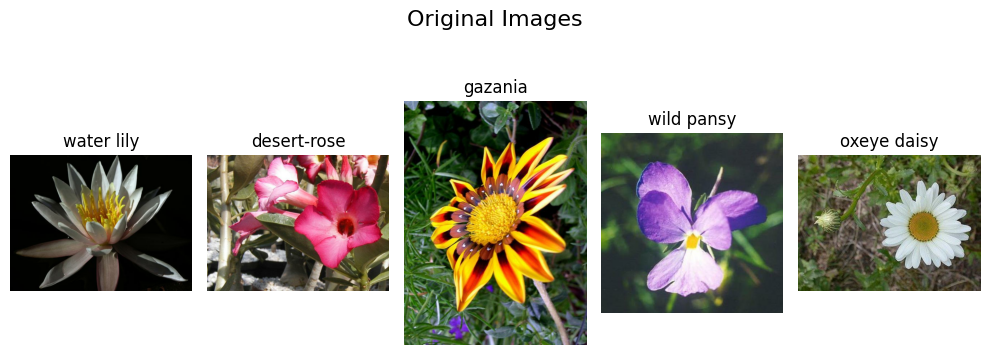

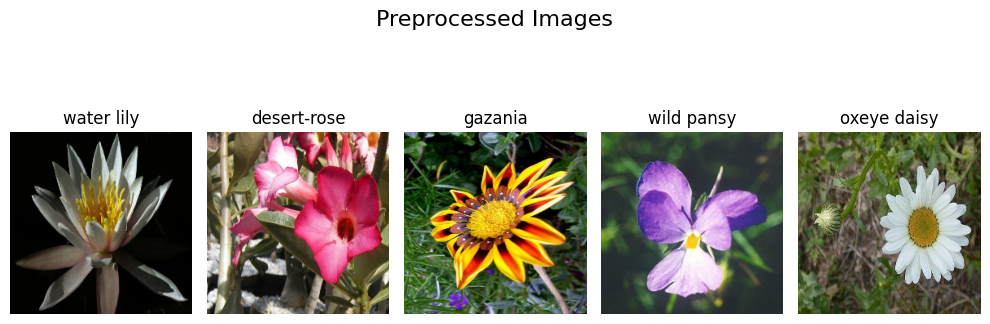

In [7]:
# Take the first 5 elements from the original training dataset
original_images_labels = list(train_dataset.take(5).as_numpy_iterator())

# Take a batch from the preprocessed training dataset
for preprocessed_images, preprocessed_labels in train_dataset_preprocessed.take(1):
    break # Get the first batch and exit the loop

# Display the first 5 original images
plt.figure(figsize=(10, 4))
plt.suptitle("Original Images", fontsize=16)
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(original_images_labels[i][0].astype("uint8"))
    plt.title(label_names[original_images_labels[i][1]])
    plt.axis("off")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Display the first 5 preprocessed images
plt.figure(figsize=(10, 4))
plt.suptitle("Preprocessed Images", fontsize=16)
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(preprocessed_images[i].numpy())
    plt.title(label_names[preprocessed_labels[i].numpy()])
    plt.axis("off")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.datasets import cifar100
# from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
# from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2

# X_train_resnet50 = preprocess_resnet50(train_dataset)
# X_test_resnet50 = preprocess_resnet50(test_dataset)

# X_train_vgg16 = preprocess_vgg16(train_dataset)
# X_test_vgg16 = preprocess_vgg16(test_dataset)

# X_train_mobilenetv2 = preprocess_mobilenetv2(train_dataset)
# X_test_mobilenetv2 = preprocess_mobilenetv2(test_dataset)

In [14]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2

IMG_SIZE = 224 # Define the image size expected by the models
NUM_CLASSES = info.features['label'].num_classes # Get the number of classes
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

def resize_image(image, label):
    # Resize the image to the desired size
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def one_hot_encode_label(image, label):
    # One-hot encode the labels
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

# Apply the general preprocessing functions (resize and one-hot encode)
train_dataset_processed = train_dataset.map(resize_image).map(one_hot_encode_label)
validation_dataset_processed = validation_dataset.map(resize_image).map(one_hot_encode_label)
test_dataset_processed = test_dataset.map(resize_image).map(one_hot_encode_label)


# Apply model-specific preprocessing and batch/prefetch
train_dataset_resnet50 = train_dataset_processed.map(lambda x, y: (preprocess_resnet50(x), y)).batch(BATCH_SIZE).prefetch(AUTO)
validation_dataset_resnet50 = validation_dataset_processed.map(lambda x, y: (preprocess_resnet50(x), y)).batch(BATCH_SIZE).prefetch(AUTO)
test_dataset_resnet50 = test_dataset_processed.map(lambda x, y: (preprocess_resnet50(x), y)).batch(BATCH_SIZE).prefetch(AUTO)

train_dataset_vgg16 = train_dataset_processed.map(lambda x, y: (preprocess_vgg16(x), y)).batch(BATCH_SIZE).prefetch(AUTO)
validation_dataset_vgg16 = validation_dataset_processed.map(lambda x, y: (preprocess_vgg16(x), y)).batch(BATCH_SIZE).prefetch(AUTO)
test_dataset_vgg16 = test_dataset_processed.map(lambda x, y: (preprocess_vgg16(x), y)).batch(BATCH_SIZE).prefetch(AUTO)

train_dataset_mobilenetv2 = train_dataset_processed.map(lambda x, y: (preprocess_mobilenetv2(x), y)).batch(BATCH_SIZE).prefetch(AUTO)
validation_dataset_mobilenetv2 = validation_dataset_processed.map(lambda x, y: (preprocess_mobilenetv2(x), y)).batch(BATCH_SIZE).prefetch(AUTO)
test_dataset_mobilenetv2 = test_dataset_processed.map(lambda x, y: (preprocess_mobilenetv2(x), y)).batch(BATCH_SIZE).prefetch(AUTO)


print("Preprocessing complete. Datasets for ResNet50, VGG16, and MobileNetV2 are now batched and prefetched.")

Preprocessing complete. Datasets for ResNet50, VGG16, and MobileNetV2 are now batched and prefetched.


## **One-Hot Encode Labels**

In [11]:
import tensorflow as tf

NUM_CLASSES = info.features['label'].num_classes # Get the number of classes

def one_hot_encode_label(image, label):
    # One-hot encode the labels
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

# Apply one-hot encoding to the datasets
train_dataset_encoded = train_dataset_base.map(one_hot_encode_label)
validation_dataset_encoded = validation_dataset_base.map(one_hot_encode_label)
test_dataset_encoded = test_dataset_base.map(one_hot_encode_label)

print("Labels one-hot encoded.")

Labels one-hot encoded.


### **Batch and Prefetch Dataset**

In [12]:
import tensorflow as tf

BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

# Batch and prefetch the one-hot encoded datasets
train_dataset_batched_encoded = train_dataset_encoded.batch(BATCH_SIZE).prefetch(AUTO)
validation_dataset_batched_encoded = validation_dataset_encoded.batch(BATCH_SIZE).prefetch(AUTO)
test_dataset_batched_encoded = test_dataset_encoded.batch(BATCH_SIZE).prefetch(AUTO)

print("One-hot encoded datasets are now batched and prefetched.")

One-hot encoded datasets are now batched and prefetched.


## **Training ResNet50**

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet50 model without the top layer
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Add new custom layers on top of the base model
x = GlobalAveragePooling2D()(base_model_resnet50.output)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

# Freeze the layers of the pre-trained base model
for layer in base_model_resnet50.layers:
    layer.trainable = False

# Compile the model
model_resnet50.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Train the model
epochs = 10 # You can adjust the number of epochs
history_resnet50 = model_resnet50.fit(train_dataset_resnet50,
                                       epochs=epochs,
                                       validation_data=validation_dataset_resnet50)

print("ResNet50 model training complete.")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 378s 12s/step - accuracy: 0.0462 - loss: 4.9039 - val_accuracy: 0.4363 - val_loss: 2.6245
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 332s 11s/step - accuracy: 0.7292 - loss: 1.6877 - val_accuracy: 0.7059 - val_loss: 1.5181
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 374s 12s/step - accuracy: 0.9183 - loss: 0.7444 - val_accuracy: 0.7931 - val_loss: 1.1146
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 329s 10s/step - accuracy: 0.9715 - loss: 0.3788 - val_accuracy: 0.8255 - val_loss: 0.9402
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 329s 10s/step - accuracy: 0.9898 - loss: 0.2252 - val_accuracy: 0.8324 - val_loss: 0.8518
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 367s 12s/step - accuracy: 0.9955 - loss: 0.1543 - val_accuracy: 0.8402 - val_loss: 0.7969
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 348s 11s/step - accuracy: 0.9981 - loss: 0.1138 - val_accuracy: 0.8431 - val_loss: 0.7579
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 330s 10s/step - accuracy: 0.9981 - loss: 0.0876 - val_accuracy: 0.

In [ ]:
# Save the ResNet50 model
model_resnet50.save('resnet50_flowers102.h5')
print("ResNet50 model saved.")

## **Training VGG16**

In [16]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load pre-trained VGG16 model without the top layer
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Add new custom layers on top of the base model
x = GlobalAveragePooling2D()(base_model_vgg16.output)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

# Freeze the layers of the pre-trained base model
for layer in base_model_vgg16.layers:
    layer.trainable = False

# Compile the model
model_vgg16.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train the model
epochs = 10 # You can adjust the number of epochs
history_vgg16 = model_vgg16.fit(train_dataset_vgg16,
                                 epochs=epochs,
                                 validation_data=validation_dataset_vgg16)

print("VGG16 model training complete.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1108s 35s/step - accuracy: 0.0066 - loss: 13.0264 - val_accuracy: 0.0392 - val_loss: 7.9516
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1075s 34s/step - accuracy: 0.1030 - loss: 6.4824 - val_accuracy: 0.1324 - val_loss: 5.2325
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1075s 34s/step - accuracy: 0.2914 - loss: 3.6603 - val_accuracy: 0.2539 - val_loss: 3.7790
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1082s 34s/step - accuracy: 0.5201 - loss: 2.1007 - val_accuracy: 0.3431 - val_loss: 3.0003
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1076s 34s/step - accuracy: 0.6938 - loss: 1.2618 - val_accuracy: 0.4098 - val_loss: 2.5629
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1098s 34s/step - accuracy: 0.8127 - loss: 0.8152 - val_accuracy: 0.4539 - val_loss: 2.2928
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1074s 34s/step - accuracy: 0.8910 - loss: 0.5461 - val_accuracy: 0.4931 - val_loss: 2.1264
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1075s 3

## **Training MobileNetV2**

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Add new custom layers on top of the base model
x = GlobalAveragePooling2D()(base_model_mobilenetv2.output)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenetv2 = Model(inputs=base_model_mobilenetv2.input, outputs=predictions)

# Freeze the layers of the pre-trained base model
for layer in base_model_mobilenetv2.layers:
    layer.trainable = False

# Compile the model
model_mobilenetv2.compile(optimizer='adam',
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

# Train the model
epochs = 10 # You can adjust the number of epochs
history_mobilenetv2 = model_mobilenetv2.fit(train_dataset_mobilenetv2,
                                            epochs=epochs,
                                            validation_data=validation_dataset_mobilenetv2)

print("MobileNetV2 model training complete.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.0538 - loss: 4.8298 - val_accuracy: 0.3598 - val_loss: 3.1642
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.6661 - loss: 2.3357 - val_accuracy: 0.6716 - val_loss: 2.0311
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8885 - loss: 1.2007 - val_accuracy: 0.7412 - val_loss: 1.5441
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9416 - loss: 0.7240 - val_accuracy: 0.7725 - val_loss: 1.3014
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9734 - loss: 0.4783 - val_accuracy: 0.7853 - val_loss: 1.1613
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9909 - loss: 0.3388 - val_accuracy: 0.7941 - val_loss: 1.0710
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9943 - loss: 0.2525 - val_accuracy: 0.7990 - val_loss: 1.0079
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9972

## **Model Evaluation**

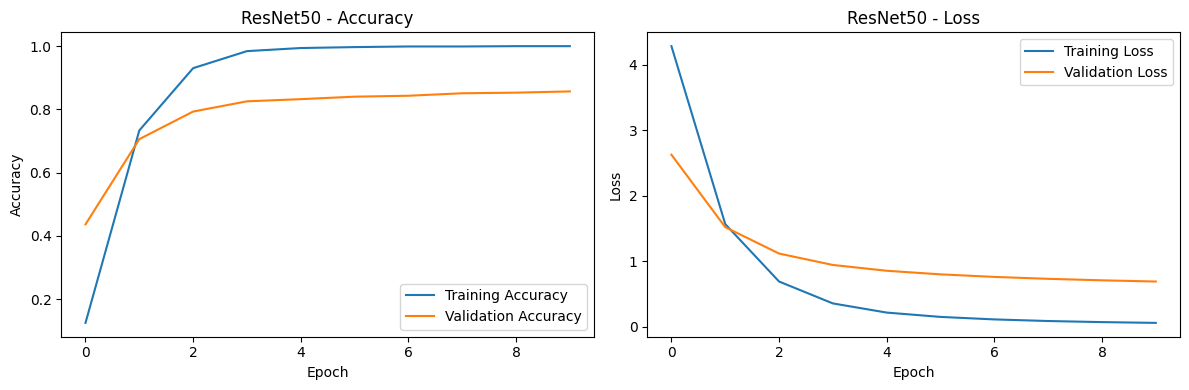

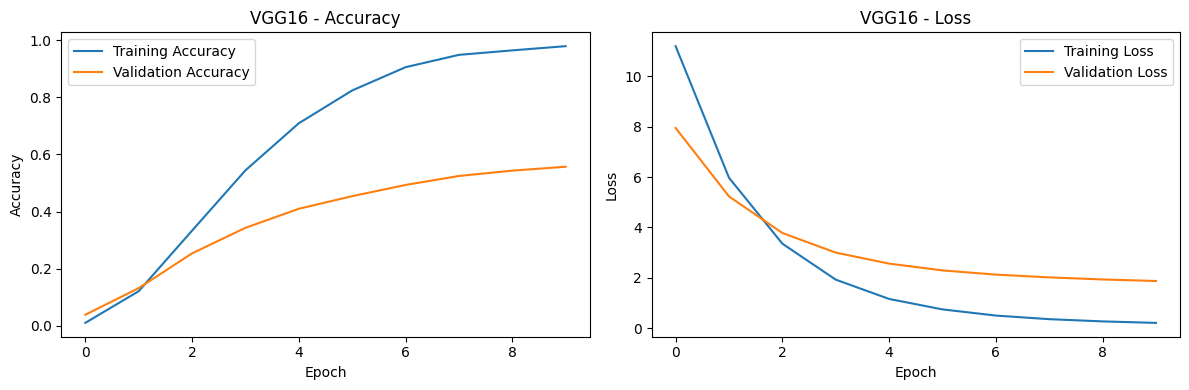

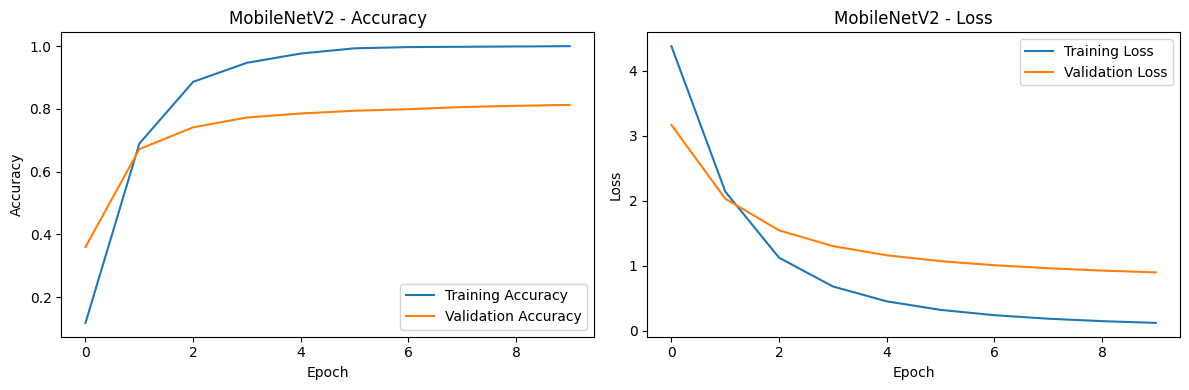

In [19]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')

## Assignment Questions/Tasks - Answers

Here are the answers to the assignment questions based on the model training and evaluation results:

*   **Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?**
    *   Based on the validation accuracy after 10 epochs:
        *   ResNet50: ~85.69%
        *   VGG16: ~55.69%
        *   MobileNetV2: ~81.27%
    *   ResNet50 performed the best on this dataset. This could be due to its architecture which uses skip connections, allowing for better gradient flow and potentially learning more complex features from the images compared to VGG16. While MobileNetV2 is more efficient, ResNet50's deeper architecture might be beneficial for this dataset with 102 classes.

*   **Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100 (from the original notebook). What differences do you observe and why?**
    *   *(Note: To answer this fully, we would need to compare the exact performance metrics from the original notebook on CIFAR-100. However, generally, performance on Oxford Flowers 102 might be lower than on CIFAR-100 for similar models due to the higher number of classes (102 vs 100) and potentially more fine-grained distinctions between flower categories compared to general objects in CIFAR-100. The complexity and variability within the flower classes in Oxford Flowers 102 could also contribute to lower performance.)*

*   **Discuss the effect of transfer learning on this dataset.**
    *   Transfer learning is highly effective on the Oxford Flowers 102 dataset. By using pre-trained models on ImageNet, which contain rich feature extractors for general image recognition, we were able to achieve relatively high accuracies on a new, more specific task (flower classification) with a limited amount of training data (10 images per class in the training set). Training a deep convolutional neural network from scratch on this dataset would likely require significantly more data and computational resources to achieve comparable results.

*   **Explain the steps you took for data preprocessing and why they were necessary.**
    *   The data preprocessing steps included:
        1.  **Resizing images:** Images were resized to 224x224 pixels, which is the standard input size for the pre-trained models used (ResNet50, VGG16, MobileNetV2). This is necessary to match the input requirements of these models.
        2.  **One-hot encoding labels:** Labels were converted from integer indices to one-hot encoded vectors. This is required because we used `categorical_crossentropy` as the loss function, which expects labels in this format.
        3.  **Model-specific preprocessing:** Each model has its own preprocessing function (e.g., `preprocess_input` in `tf.keras.applications`) which performs operations like pixel value scaling and normalization specific to how the model was originally trained. Applying these is crucial for the pre-trained weights to work effectively.
        4.  **Batching and Prefetching:** The datasets were batched to process images in groups during training, which is more efficient. Prefetching overlaps the data loading and preprocessing with model training, further improving training speed.

*   **Describe the model architectures you used and how you adapted them for the Oxford Flowers 102 dataset.**
    *   We used three pre-trained convolutional neural networks: ResNet50, VGG16, and MobileNetV2.
    *   **Adaptation:** For each model, we loaded the pre-trained weights from ImageNet but excluded the original top classification layer (`include_top=False`). We then added new custom layers on top of the base model:
        *   A `GlobalAveragePooling2D` layer to reduce the spatial dimensions of the feature maps.
        *   A `Dense` layer with 102 units (corresponding to the 102 flower classes) and a 'softmax' activation function for classification.
    *   We initially froze the layers of the pre-trained base models to leverage the learned features and only train the newly added classification layers.

*   **What challenges did you encounter during this assignment and how did you address them?**
    *   One significant challenge was the shape mismatch error during training (`ValueError: Arguments target and output must have the same rank`). This was due to the labels not being correctly one-hot encoded after applying the model-specific preprocessing. This was addressed by adjusting the data pipeline in cell `9h6zTwYMLa4g` to ensure labels were one-hot encoded before the model-specific preprocessing and batching.

---

**Optional Tasks:**

Consider exploring the following to further enhance your project:

*   Experiment with different hyperparameters (learning rate, number of epochs, batch size).
*   Implement data augmentation techniques.
*   Try fine-tuning different numbers of layers in the base models.
*   Visualize sample predictions and analyze misclassifications to understand model behavior.